In [1]:
a=55
a

55

In [2]:
type(a)

int

Training set shape: (60000, 28, 28)
Testing set shape: (10000, 28, 28)


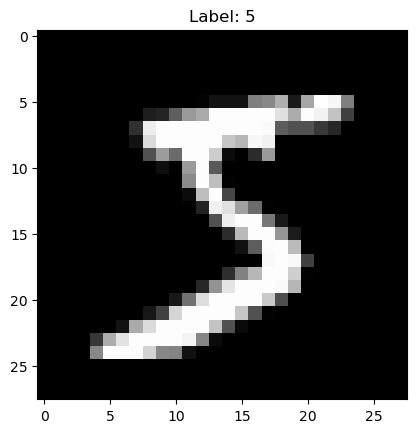

E:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7808 - loss: 0.7012 - val_accuracy: 0.9763 - val_loss: 0.0827
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9635 - loss: 0.1208 - val_accuracy: 0.9821 - val_loss: 0.0585
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9734 - loss: 0.0905 - val_accuracy: 0.9868 - val_loss: 0.0467
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9801 - loss: 0.0693 - val_accuracy: 0.9881 - val_loss: 0.0414
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9838 - loss: 0.0566 - val_accuracy: 0.9873 - val_loss: 0.0416
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9851 - loss: 0.0503 - val_accuracy: 0.9899 - val_loss: 0.0379
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9864 - loss: 0.0451 - val_accuracy: 0.9890 - val_loss: 0.0357
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9881 - loss: 0.0379 - val_acc

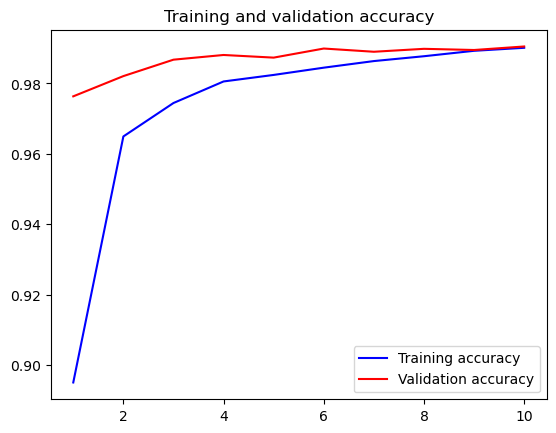

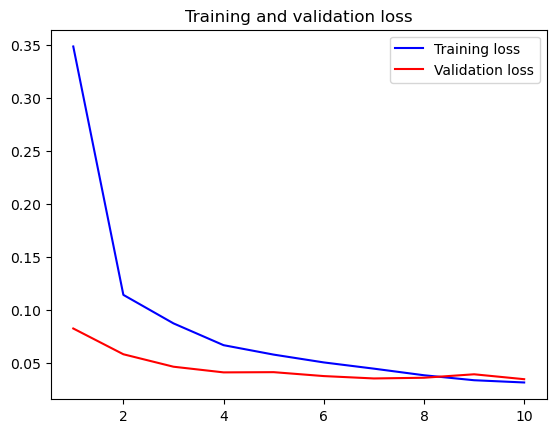

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted digit: 7


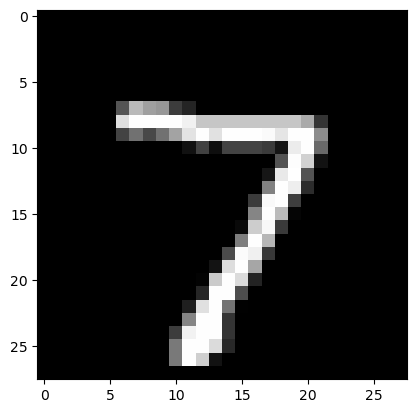

In [3]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load MNIST dataset from Keras
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Explore the dataset
print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

# Display the first image in the dataset
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# Data Preprocessing
# Normalize the pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape the data to add a channel dimension (needed for CNNs)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Build a deep learning model (Convolutional Neural Network)
model = models.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),  # Flatten the 2D output into 1D
    layers.Dense(128, activation='relu'),  # Fully connected layer
    layers.Dropout(0.5),  # Dropout to prevent overfitting
    layers.Dense(10, activation='softmax')  # Output layer (10 classes for 10 digits)
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model Summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")

# Plot training & validation accuracy and loss over epochs
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Accuracy plot
    plt.plot(epochs, acc, 'b', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.figure()

    # Loss plot
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.show()

# Plot the training history
plot_training_history(history)

# Predict on a test image
import numpy as np
image_index = 0  # Change the index to test different images
pred = model.predict(X_test[image_index].reshape(1, 28, 28, 1))
print(f"Predicted digit: {np.argmax(pred)}")

# Show the corresponding test image
plt.imshow(X_test[image_index].reshape(28, 28), cmap='gray')
plt.show()


In [4]:
b=12
b

12

In [5]:
type(b)

int

In [6]:
for i in range(1,13):
    print(i)

1
2
3
4
5
6
7
8
9
10
11
12


In [7]:
i=0
while(i<101):
    print(i)
    i = i + 1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [11]:
a=int(input("enter the number"))
a
if(a>14):
    print("variable is greater")
elif(a==14):
    print("variable is equal")
else:
    print("variable is not greater")

enter the number 14


variable is equal


In [12]:
c="he"
d="ch"
c+d

'hech'

In [13]:
c+'  '+d

'he  ch'

In [14]:
c+d



'hech'

In [15]:
a=1.5
b=1.4
a+b

2.9

In [16]:
a

1.5

In [17]:
b

1.4

In [18]:
a

1.5

In [19]:
b

1.4

In [20]:
d="aa"
d

'aa'

In [21]:
type(d)

str